In [1]:
import qutip as qt
from qutip import tensor, basis, qeye
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.gate_extender import Gate_extender, Convert_levels
from quantum_logical.trotterization import Trotterization

In [2]:
def gate(dim, N):
    # creating the gates
    dim = dim
    N = N
    # creating the set of cnots (this will operate between the g and e levels)
    cnot_create = Convert_levels(num_qubits=N)
    cnot1 = cnot_create.Cnot(dim=3, target=1, control=0, high=2, low=0)
    cnot2 = cnot_create.Cnot(dim=3, target=2, control=0, high=2, low=0)

    cnot3 = cnot_create.Cnot(dim=3, target=3, control=0, high=1, low=0)
    cnot4 = cnot_create.Cnot(dim=3, target=3, control=1, high=1, low=0)
    
    cnot5 = cnot_create.Cnot(dim=3, target=3, control=1, high=1, low=0)
    cnot6 = cnot_create.Cnot(dim=3, target=3, control=2, high=1, low=0)

    # the x_gate needs to be made in a qutrit gate and will involve conversion 
    x_gate = qt.Qobj([[0, 1],[1, 0]])


    hada = qt.Qobj([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0], [1/np.sqrt(2), 0, -1/np.sqrt(2)]])


    gate_extention = Gate_extender(num_qubits=1)
    x_gate = gate_extention.qubit_to_qudit(gate=x_gate, from_dim=2, to_dim=dim)


    # conversion of some of the gates into the qutrit space 
    new_dim = dim
    converter = Convert_levels(num_qubits=1)
    x_gate = converter.level_conversion(levels=[0,2], dim=dim, gate=x_gate, qubits=None)


    x_layer = tensor(tensor([x_gate] * 3), tensor([qeye(new_dim)] * 2))
    hada_layer = tensor(tensor([hada] * 3), tensor([qeye(new_dim)] * 2))

    # building the correction z_gate 
    correction_x = qt.Qobj([[0, 1],[1, 0]])
    gate_extention = Gate_extender(num_qubits=1)
    correction_x = gate_extention.qubit_to_qudit(gate=correction_x, from_dim=2, to_dim=3)
    converter = Convert_levels(num_qubits=1)
    correction_x = converter.level_conversion(levels=[1,2], dim=new_dim, gate=correction_x, qubits=None)

    correction_z = (hada * correction_x * hada.dag())

    # vector setup 
    basis0 = qt.Qobj([[1],[0],[0]])
    basis1 = qt.Qobj([[0],[1],[0]])
    basis2 = qt.Qobj([[0],[0],[1]])
    vector0 = hada * basis0
    vector1 = hada * basis1
    vector2 = hada * basis2
    vectors = [vector0, vector1, vector2]
    vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]

    cnots = [cnot1, cnot2, cnot3, cnot4, cnot5, cnot6]
    return cnots, correction_z, hada_layer, x_layer, vectors

In [3]:
from notebooks.logical_errors.characterization_sims.simulation_tools_erasure_repetition_3_wave_step_down import state

In [4]:
def repetition_correction(values, rho_initial, total_time):
    cnots = values[0]
    # rho_encoded = values[1]
    ref_state = values[2]
    arrays = values[3]
    dim = values[4]
    N = values[5]
    x_layer = values[6]
    correction_z = values[7]
    hada_layer = values[8]
    vectors = values[9]

    trotter_dt = .01
    cnot3 = cnots[0]
    cnot4 = cnots[1]
    cnot5 = cnots[2]
    cnot6 = cnots[3]

    # initializing Trotterization
    trotter = Trotterization(trotter_dt=trotter_dt, T1=arrays[0], T2=arrays[1], dim=dim, num_qubits=N, qudit="qutrit")

    initial_state = qt.ptrace(rho_initial, [0,1,2])
    ancilla_states = tensor(basis(dim, 0), basis(dim, 0)) * tensor(basis(dim, 0), basis(dim, 0)).dag()
    full_initial_state = tensor(initial_state, ancilla_states)
    
    # stored information
    states = []

    def neilson_fid(rho, sigma):
        return (((rho.sqrtm()) * sigma * (rho.sqrtm())).sqrtm()).tr()
    
    fids = []

    # gate setups 
    gates = [[x_layer], [cnot3], [cnot4], [cnot5], [cnot6], [x_layer]]
    cnot_time = .5
    gate_times = [.03, cnot_time, cnot_time, cnot_time, cnot_time, .03]

    # stabilizer extraction
    rho_encoded = hada_layer * full_initial_state * hada_layer.dag()

    for i in range(len(gates)):
        trotter_dt = gate_times[i] / 20
        trotter = Trotterization(trotter_dt=trotter_dt, T1=arrays[0], T2=arrays[1], dim=dim, num_qubits=N, qudit="qutrit")
        rho_evo = trotter.apply(rho=rho_encoded, duration=gate_times[i], unitary=gates[i], errors=True)
        states.extend(rho_evo)
        rho_encoded = rho_evo[-1]
        total_time += gate_times[i]

        
    states.append(hada_layer * rho_encoded * hada_layer.dag())
    fids.append(np.abs(neilson_fid(rho=qt.ptrace(states[-1], [0,1,2]), sigma=qt.ptrace(ref_state, [0,1,2]))))


    # projection operators  
    proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) 
            for i in range(2) for j in range(2)]


    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), correction_z, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(correction_z, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), correction_z, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
    recovery_ops = [[r00], [r01], [r10], [r11]]
    
    # measurement 
    measured_states = []
    measurement_duration = 2
    trotter_dt = measurement_duration / 20
    trotter = Trotterization(trotter_dt=trotter_dt, T1=arrays[0], T2=arrays[1], dim=dim, num_qubits=N, qudit="qutrit")
    measurement_delay_evo = trotter.apply(rho=states[-1], duration=measurement_duration, unitary=[tensor([qt.qeye(dim)] * N)], errors=True)
    measured_states.append(measurement_delay_evo)
    proj_results_after_measurement = [(measurement_delay_evo[-1] * proj).tr() for proj in proj]
    proj_states_after_measurment = [(proj * measurement_delay_evo[-1] * proj.dag()) for proj in proj]
    total_time += measurement_duration

    corrected_states = []
    recovery_duration = .03
    for i in range(len(recovery_ops)):
        if proj_results_after_measurement[i] != 0:
            trotter_dt = recovery_duration / 20
            trotter = Trotterization(trotter_dt=trotter_dt, T1=arrays[0], T2=arrays[1], dim=dim, num_qubits=N, qudit="qutrit")
            corrected_state = trotter.apply(proj_states_after_measurment[i], duration=recovery_duration, unitary=recovery_ops[i], errors=True)
            corrected_states.append(corrected_state)
        else:
            corrected_states.append([recovery_ops[i][0] * proj_states_after_measurment[i] * recovery_ops[i][0].dag()] *int(recovery_duration/ trotter_dt))

    total_time += recovery_duration
    # combining the branches 
    repetition_corrected_state = sum([proj_results_after_measurement[j] * corrected_states[j][-1] for j in range(len(proj_results_after_measurement))])
    
    return repetition_corrected_state, total_time

In [5]:
# make sure to reset the ancillas 
def erasure_correction(rho, N, T, total_time):
    initial_state = qt.ptrace(rho, [0,1,2])
    ancilla_states = tensor(basis(dim, 0), basis(dim, 0), basis(dim, 0)) * tensor(basis(dim, 0), basis(dim, 0), basis(dim, 0)).dag()
    full_initial_state = tensor(initial_state, ancilla_states)

    # detection gate creation
    cnot_create = Convert_levels(num_qubits=N)
    cnot1 = cnot_create.Cnot(dim=3, target=3, control=0, high=1, low=0)
    cnot2 = cnot_create.Cnot(dim=3, target=4, control=1, high=1, low=0)
    cnot3 = cnot_create.Cnot(dim=3, target=5, control=2, high=1, low=0)


    hada = qt.Qobj([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0], [1/np.sqrt(2), 0, -1/np.sqrt(2)]])
    hada_layer = tensor(tensor([hada] * 3), tensor([qeye(dim)] * 3))

    trotter_dt = .01

    gates = [cnot1, cnot2, cnot3]
    cnot_time = .5
    gate_times = [cnot_time for _ in range(len(gates))]

    trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qutrit")
    
    # running the circuit 
    rho_encoded = hada_layer * full_initial_state * hada_layer.dag()


    for i in range(len(gates)):
        trotter_dt = gate_times[i] / 20
        trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qutrit")

        rho_evo = trotter.apply(rho=rho_encoded, duration=gate_times[i], unitary=[gates[i]], errors=True)
        rho_encoded = rho_evo[-1]
        total_time += gate_times[i]
    
    # measurement
    # measurement operators 
    proj = [tensor(qeye(dim), qeye(dim), qeye(dim), tensor(basis(dim, i), basis(dim, j), basis(dim, k))  * tensor(basis(dim, i), basis(dim, j), basis(dim, k)).dag()) 
             for i in [0,1] for j in [0,1] for k in [0,1]]
    
    measurement_duration = 2
    trotter_dt = measurement_duration / 20
    trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qutrit")

    measurement_evo = trotter.apply(rho=rho_encoded, duration=measurement_duration, unitary=[tensor([qeye(dim)] * N)], errors=True)
    total_time += measurement_duration

    # projection results
    proj_res = [(proj * measurement_evo[-1]).tr() for proj in proj]
    proj_states = [(proj * measurement_evo[-1] * proj.dag()) for proj in proj]
   

    # Correction based on the results 
    # correction gates
    cnot_create = Convert_levels(num_qubits=N)
    cnot1 = cnot_create.Cnot(dim=3, target=2, control=0, high=2, low=1)
    cnot2 = cnot_create.Cnot(dim=3, target=1, control=0, high=2, low=1)
    cnot3 = cnot_create.Cnot(dim=3, target=0, control=1, high=2, low=1)
    cnot4 = cnot_create.Cnot(dim=3, target=2, control=1, high=2, low=1)
    cnot5 = cnot_create.Cnot(dim=3, target=0, control=2, high=2, low=1)
    cnot6 = cnot_create.Cnot(dim=3, target=1, control=2, high=2, low=1)
    
    # correction_operators
    r000 = [qt.tensor([qt.qeye(dim)] * N)]
    r001 = [cnot1]
    r010 = [cnot2]
    r011 = [cnot2, cnot1]
    r100 = [cnot3]
    r101 = [cnot3, cnot4]
    r110 = [cnot5, cnot6]
    r111 = [qt.tensor([qt.qeye(dim)] * N)]

    recovery_ops = [r000, r001, r010, r011, r100, r101, r110, r111]


    # start the correction procedure 
    # correction_cycle 
    correction_duration = .5
    corrected_states = []
    for i in range(len(recovery_ops)):
        if proj_res[i] != 0:
            trotter_dt = correction_duration / 20
            trotter = Trotterization(trotter_dt=trotter_dt, T1=T[0], T2=T[1], dim=dim, num_qubits=N, qudit="qutrit")

            corrected_state = trotter.apply(proj_states[i], duration=correction_duration, unitary=recovery_ops[i], errors=True)
            corrected_states.append(corrected_state)
        else:
            corrected_states.append([recovery_ops[i][0] * proj_states[i] * (recovery_ops[i][0]).dag()] * int(correction_duration/ trotter_dt))
    total_time += correction_duration

    # combining the corrected states
    erasure_corrected_state = sum([proj_res[j] * corrected_states[j][-1] for j in range(len(proj_res))])

    erasure_corrected_state = hada_layer * erasure_corrected_state * hada_layer.dag()
    
    return erasure_corrected_state, total_time

In [6]:
from notebooks.logical_errors.characterization_sims.simulation_tools_erasure_repetition_3_wave_step_down import state

In [7]:
N = 5
dim = 3
cnots, correction_z, hada_layer, x_layer, vectors = gate(dim=dim, N=N)
choice = [1, 0, [2,2,2], [2,2,2]]
rho_encoded, ref_state = state(alpha=choice[0], beta=choice[1], N=N, qubit_choice=choice[2], qubit_ref=choice[3], dim=dim)

In [8]:
hada = qt.Qobj([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0], [1/np.sqrt(2), 0, -1/np.sqrt(2)]])
# vector setup 
basis0 = qt.Qobj([[1],[0],[0]])
basis1 = qt.Qobj([[0],[1],[0]])
basis2 = qt.Qobj([[0],[0],[1]])
vector0 = hada * basis0
vector1 = hada * basis1
vector2 = hada * basis2
vectors = [vector0, vector1, vector2]
vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]

In [9]:
# t1_list = np.linspace(4, 650, 100)

iterations = 1
t1_list = np.linspace(100, 100, iterations)
t_list = []
for i in range(len(t1_list)):
    t2s = np.linspace(t1_list[i], 2 * t1_list[i] - 1, 1)
    # t2s = np.linspace(1, 2* t1_list[i] - 1, 1)
    for j in range(len(t2s)):
        t_list.append([t1_list[i], t2s[j]])


cnots = [cnots[2], cnots[3], cnots[4], cnots[5]]

values = []
for i in range(len(t_list)):
    values.append([cnots, rho_encoded, ref_state, t_list[i], dim, N, x_layer, correction_z, hada_layer, vectors])

# fid_tops = []
# fid_base = []
# lifetime_gain = []

physical_error = []
logical_error = []
t1 = []
t2 = []
time = []
physical_err = []

cycles = 80

for value in values:
    choice = [1, 0, [2,2,2], [2,2,2]]
    rho_encoded, ref_state = state(alpha=choice[0], beta=choice[1], N=N, qubit_choice=choice[2], qubit_ref=choice[3], dim=dim)

    order = [0]
    # order = [0]
    total_time = 0
    for i in tqdm(range(cycles)):
        for choice in order:
            if choice == 0:
                rho_encoded, total_time = repetition_correction(values=value, rho_initial=rho_encoded, total_time=total_time)
                # print(total_time)
            elif choice == 1:
                rho_encoded, total_time = erasure_correction(rho=rho_encoded, N= (N + 1), T=value[3], total_time=total_time)
                # print(total_time)

        # def neilson_fid(rho, sigma):
        #     return (((rho.sqrtm()) * sigma * (rho.sqrtm())).sqrtm()).tr()
        def neilson_fid(rho, sigma):
            return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

        # qubit baseline result
        # trotter = Trotterization(trotter_dt=.01, T1=value[3][0], T2=value[3][1], dim=2, num_qubits=1, qudit="qubit")
        # # hada = (1 / np.sqrt(2)) * qt.Qobj([[1, 1], [1, -1]])
        # # qubit_baseline = trotter.apply(rho=hada * (basis(2, 1) * basis(2, 1).dag()) * hada.dag(), duration=total_time, unitary=[qeye(2)], errors=True)
        # qubit_baseline = trotter.apply(rho=(basis(2, 1) * basis(2, 1).dag()), duration=total_time, unitary=[qeye(2)], errors=True)


        # fid_baseline = np.abs(neilson_fid(rho=qubit_baseline[-1], sigma=(basis(2, 1) * basis(2, 1).dag())))

        fid_topology = np.abs(neilson_fid(rho=qt.ptrace(rho_encoded, [0,1,2]), sigma=qt.ptrace(ref_state, [0,1,2])))

        # fid_tops.append(fid_topology)
        # fid_base.append(fid_baseline)
        # lifetime_gain.append(np.log(fid_baseline) / np.log(fid_topology))


        logical = [vectors[-1]]
        vals = []
        for vec in logical:
            val = (vec.dag() * qt.ptrace(rho_encoded, [0,1,2]) * vec)[0][0][0]
            vals.append(val)
        logical_error.append(np.abs(1 - np.abs(sum(vals))))
        # logical_error_rate_over_time.append(np.abs(logical_error[-1] / total_time))

        # vector1 = qt.Qobj([[0],[1]])

        # physical_error_val = 1 - (vector1.dag() * qubit_baseline[-1] * vector1)[0][0][0]
        t_phase = (2 * value[3][0] * value[3][1])/(2 * value[3][0] - value[3][1])
        physical_error_val = 1 - np.exp((-total_time) * ((1/value[3][0]) + (1/t_phase)))
        physical_error.append(np.abs(physical_error_val))
        physical_err.append(((1/value[3][0]) + (1/t_phase)))
        # physical_error_time.append(np.abs(physical_error[-1] / total_time))
        t1.append(value[3][0])
        t2.append(value[3][1])
        time.append(total_time)


100%|██████████| 80/80 [02:34<00:00,  1.94s/it]


In [10]:
import csv

# Writing the arrays to a CSV file
with open('6_qutrit_3_wave_top_cycles_t1_100_t2_100_0.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(physical_error)  
    writer.writerow(logical_error)  
    writer.writerow(t1)  
    writer.writerow(t2)  
    writer.writerow(time)  
    writer.writerow(physical_err)  

In [11]:
%%capture
vals = []
for vec in vectors:
    val = (vec.dag() * qt.ptrace(erasure_corrected_state, [0,1,2]) * vec)[0][0][0]
    vals.append(val)
vals

NameError: name 'erasure_corrected_state' is not defined

NameError: name 'lifetime_gain' is not defined

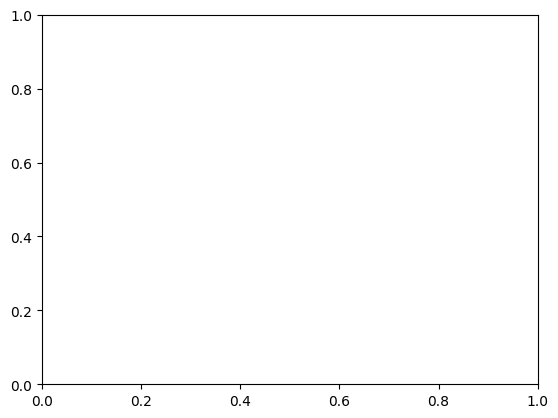

In [12]:
# plot the lifetime gain against the decoherence times 
fig, ax = plt.subplots()
ax.plot(t1_list, lifetime_gain)
ax.set_xlabel("Decoherence (microseconds)")
ax.set_ylabel("Lifetime Gain")
ax.set_title("Lifetime Gain vs Decoherence") 

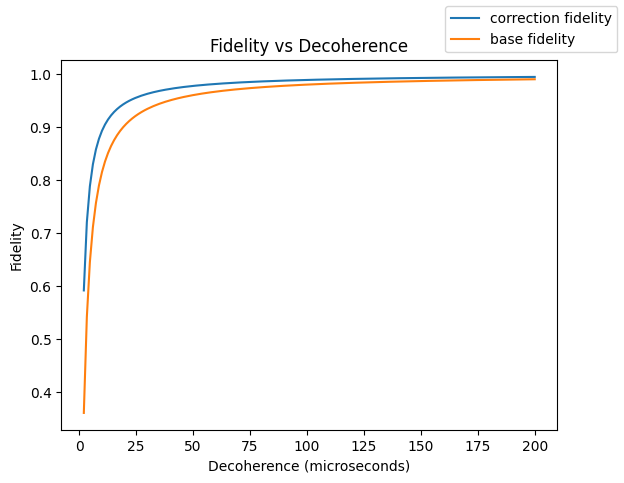

In [ ]:
fig, ax = plt.subplots()
ax.plot(t1_list, fid_tops, label = "correction fidelity")
ax.plot(t1_list, fid_base, label = "base fidelity")
ax.set_xlabel("Decoherence (microseconds)")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs Decoherence")
fig.legend()